# Task
apply
TabNet (Deep Learning for Tabular Data)
FT-Transformer (Feature Tokenizer Transformer)
NODE (Neural Oblivious Decision Ensembles)
CatBoost
LightGBM
XG BOOST
RF

Here is all the data you need:
"water_potability.csv"

## Data loading

### Subtask:
Load the water potability dataset.


**Reasoning**:
Import pandas and load the water potability dataset into a DataFrame named `df`.



In [2]:
import pandas as pd

df = pd.read_csv('/content/water_potability.csv')
display(df.head())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## Data exploration

### Subtask:
Explore the water potability dataset to understand its characteristics.


**Reasoning**:
Explore the shape, data types, missing values, and descriptive statistics of the DataFrame.



In [3]:
# Examine the shape of the data
print(f"Shape of the data: {df.shape}")

# Check data types
print("\nData types of each column:")
print(df.dtypes)

# Analyze missing values
print("\nNumber of missing values in each column:")
print(df.isnull().sum())

# Examine the distribution of features for numerical features
print("\nDescriptive statistics for numerical features:")
display(df.describe())

Shape of the data: (3276, 10)

Data types of each column:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

Number of missing values in each column:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Descriptive statistics for numerical features:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


**Reasoning**:
Analyze the distribution of numerical features using histograms and box plots, and explore the correlation between features.



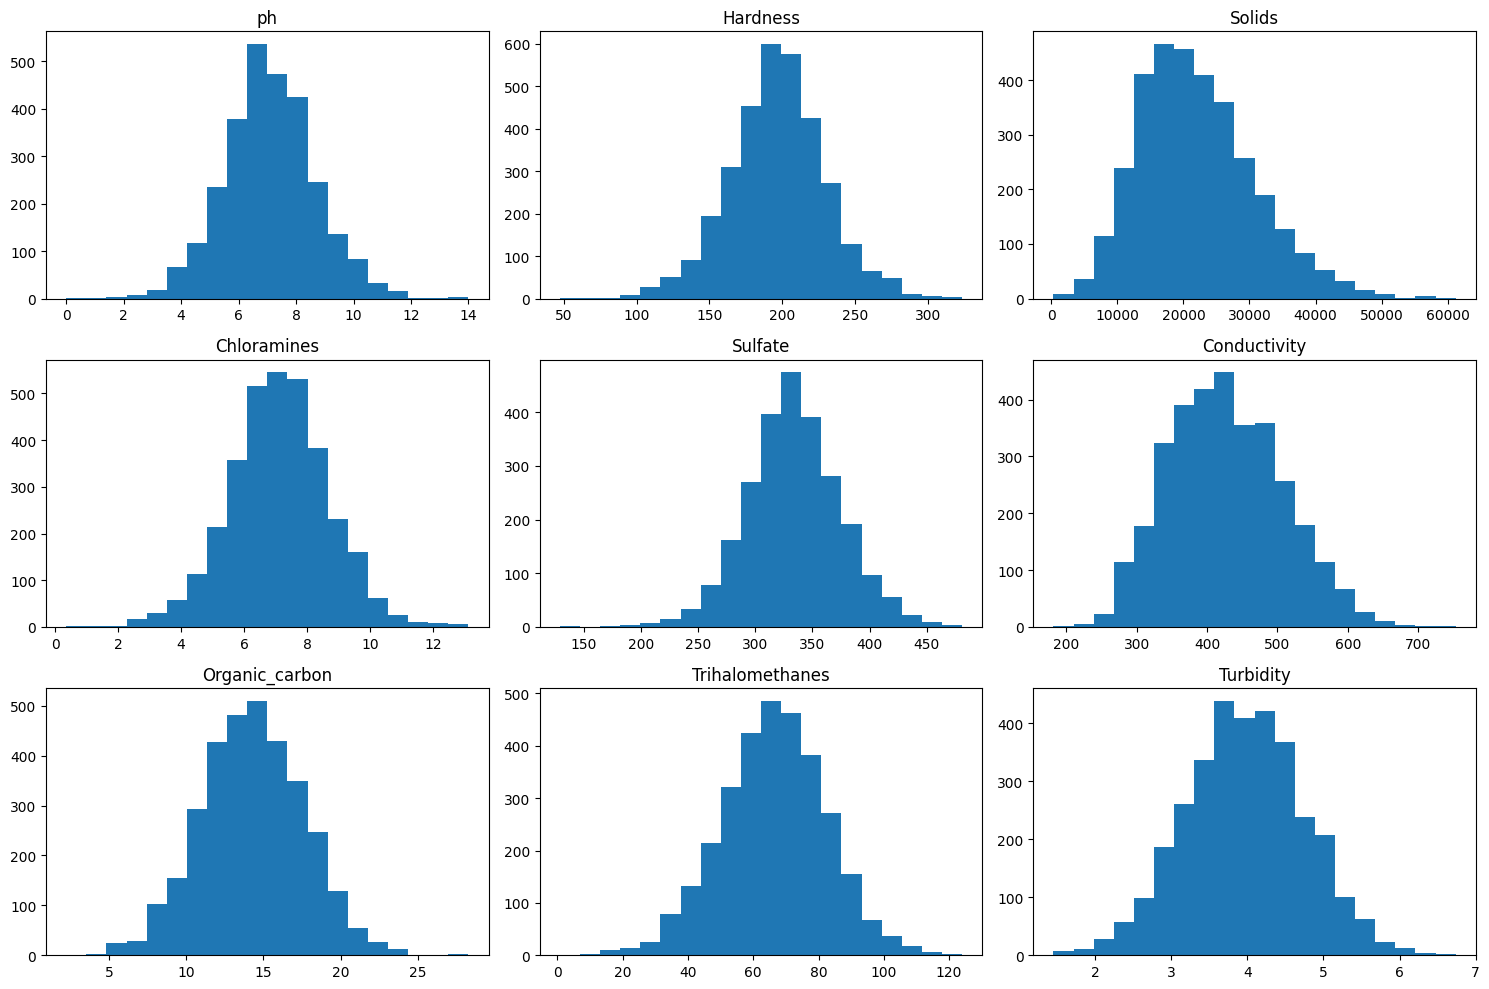

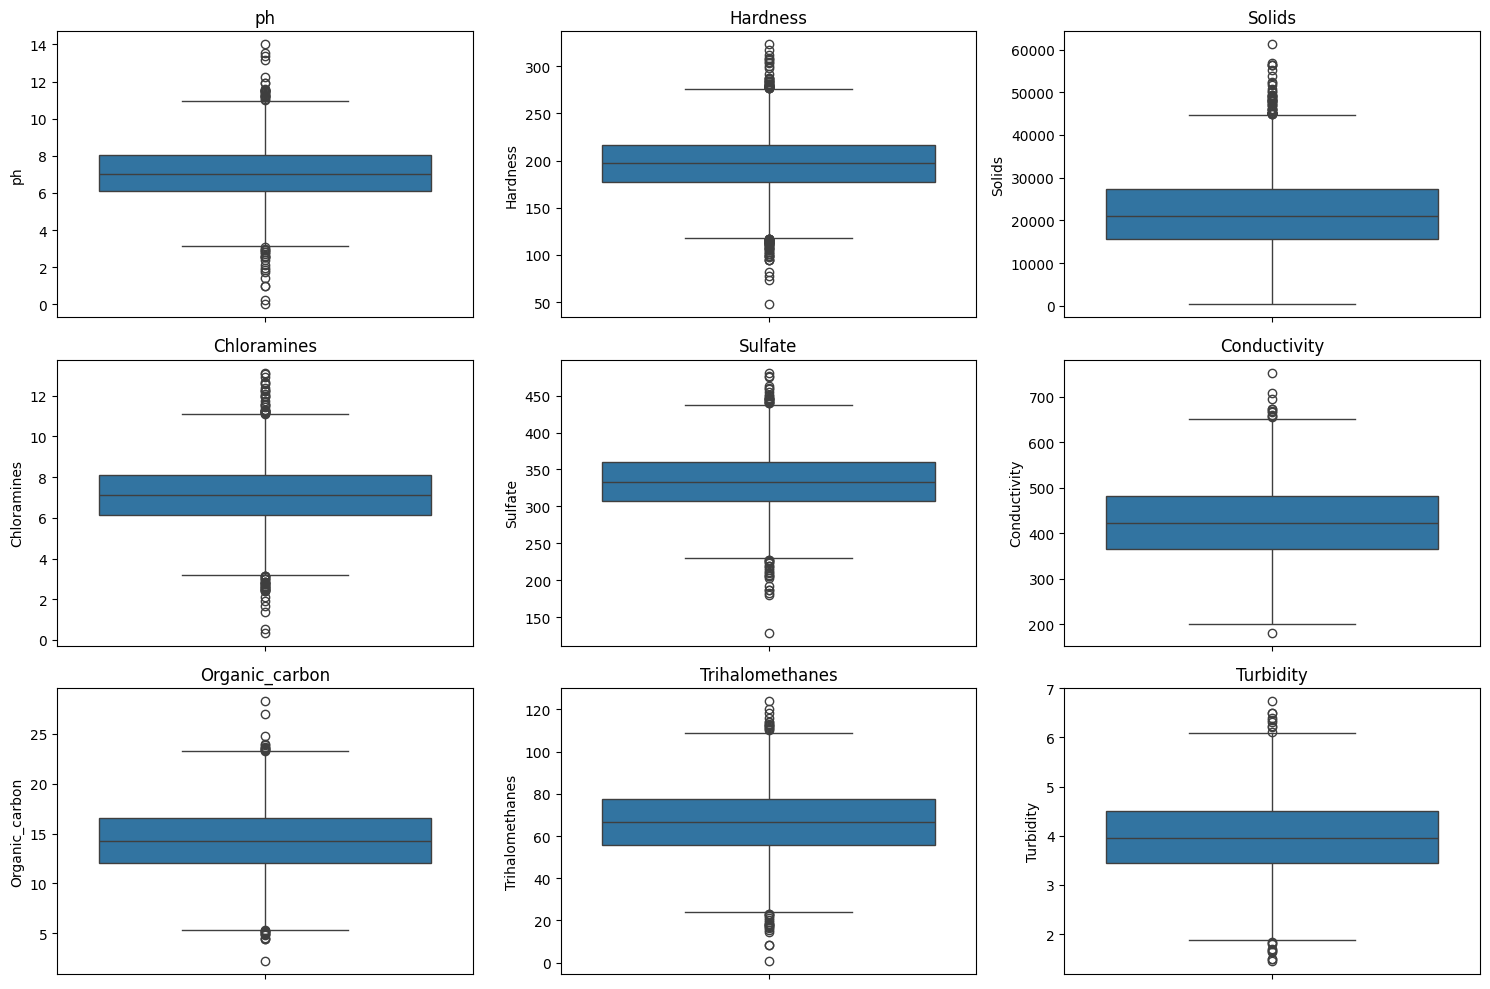

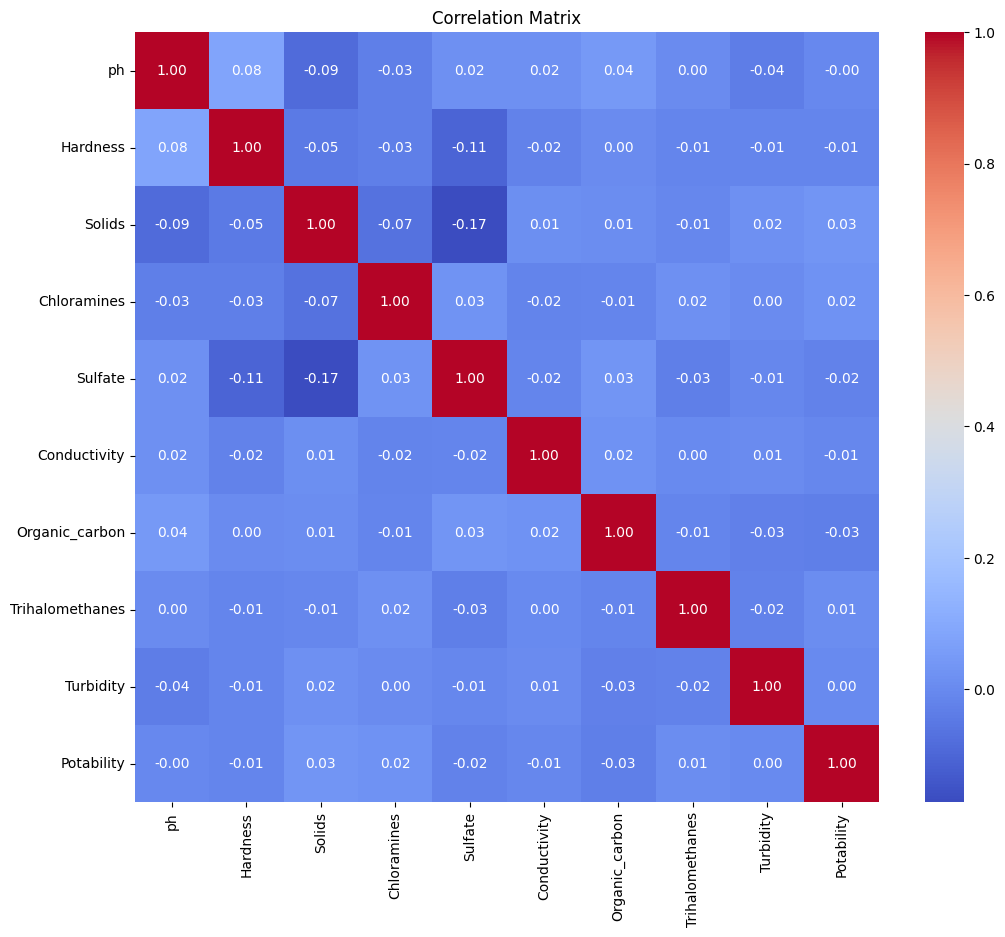

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.select_dtypes(include=['float64']).columns):
    plt.subplot(3, 3, i + 1)
    plt.hist(df[col].dropna(), bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()

# Box plots for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.select_dtypes(include=['float64']).columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Correlation matrix
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

**Reasoning**:
Examine the distribution of the target variable ('Potability') and determine the proportion of positive and negative instances.



In [5]:
# Examine the distribution of the target variable
print("\nDistribution of the target variable 'Potability':")
print(df['Potability'].value_counts())

# Calculate the proportion of positive and negative instances
total_instances = len(df)
positive_instances = df['Potability'].sum()
negative_instances = total_instances - positive_instances
positive_proportion = positive_instances / total_instances
negative_proportion = negative_instances / total_instances

print(f"\nProportion of positive instances: {positive_proportion:.2f}")
print(f"Proportion of negative instances: {negative_proportion:.2f}")


Distribution of the target variable 'Potability':
Potability
0    1998
1    1278
Name: count, dtype: int64

Proportion of positive instances: 0.39
Proportion of negative instances: 0.61


## Data cleaning

### Subtask:
Handle missing values in the dataset.


**Reasoning**:
Identify the columns with missing values and impute them with the median.



In [6]:
# Identify columns with missing values
cols_with_missing = df.columns[df.isnull().any()].tolist()

# Impute missing values with the median for each column
for col in cols_with_missing:
    df[col].fillna(df[col].median(), inplace=True)

# Create a new DataFrame df_cleaned
df_cleaned = df.copy()

<ipython-input-6-d30f934f1d19>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


**Reasoning**:
Fix the warning from the previous code block and create a new DataFrame `df_cleaned` without missing values.



In [7]:
# Identify columns with missing values
cols_with_missing = df.columns[df.isnull().any()].tolist()

# Impute missing values with the median for each column
for col in cols_with_missing:
  df[col] = df[col].fillna(df[col].median())

# Create a new DataFrame df_cleaned
df_cleaned = df.copy()

## Data splitting

### Subtask:
Split the cleaned dataset into training, validation, and test sets.


**Reasoning**:
Split the cleaned dataset into training, validation, and test sets as per the instructions.



In [8]:
from sklearn.model_selection import train_test_split

# Split into training and combined validation/test sets
df_train, df_combined = train_test_split(df_cleaned, test_size=0.2, random_state=42)

# Further split the combined validation/test set into validation and test sets
df_val, df_test = train_test_split(df_combined, test_size=0.5, random_state=42)

## Data preparation

### Subtask:
Prepare the training, validation, and test datasets for model training.


**Reasoning**:
Separate the target variable from the features, scale the numerical features using StandardScaler, and prepare the datasets for model training.



In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate target variable from features
X_train = df_train.drop('Potability', axis=1)
y_train = df_train['Potability']
X_val = df_val.drop('Potability', axis=1)
y_val = df_val['Potability']
X_test = df_test.drop('Potability', axis=1)
y_test = df_test['Potability']

# Scale numerical features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Model training

### Subtask:
Train the following models using the prepared training data (X_train, y_train):
* TabNet
* FT-Transformer
* NODE
* CatBoost
* LightGBM
* XGBoost
* Random Forest (RF)


**Reasoning**:
Import necessary libraries and train the specified models using the prepared training data (X_train, y_train).



**Reasoning**:
The previous code block failed due to a missing package. Install the required package 'pytorch-tabnet'.



**Reasoning**:
The task is to perform a linear regression on the dataset. Before that, we need to load the data and prepare it for the model.



/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
<ipython-input-4-9d2106e500a7>:50: UserWarning: No early stopping will be performed, last training weights will be used.
  model.fit(X_train, y_train.values.ravel())  # Convert y_train to 1D


[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000358 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3473: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  if (await self.run_code(code, result,  async_=asy)):
/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3473: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  if (await self.run_code(code, result,  async_=asy)):
/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3473: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  if (await self.run_code(code, result,  async_=asy)):
/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3473: UserWarning: set_ticklabe

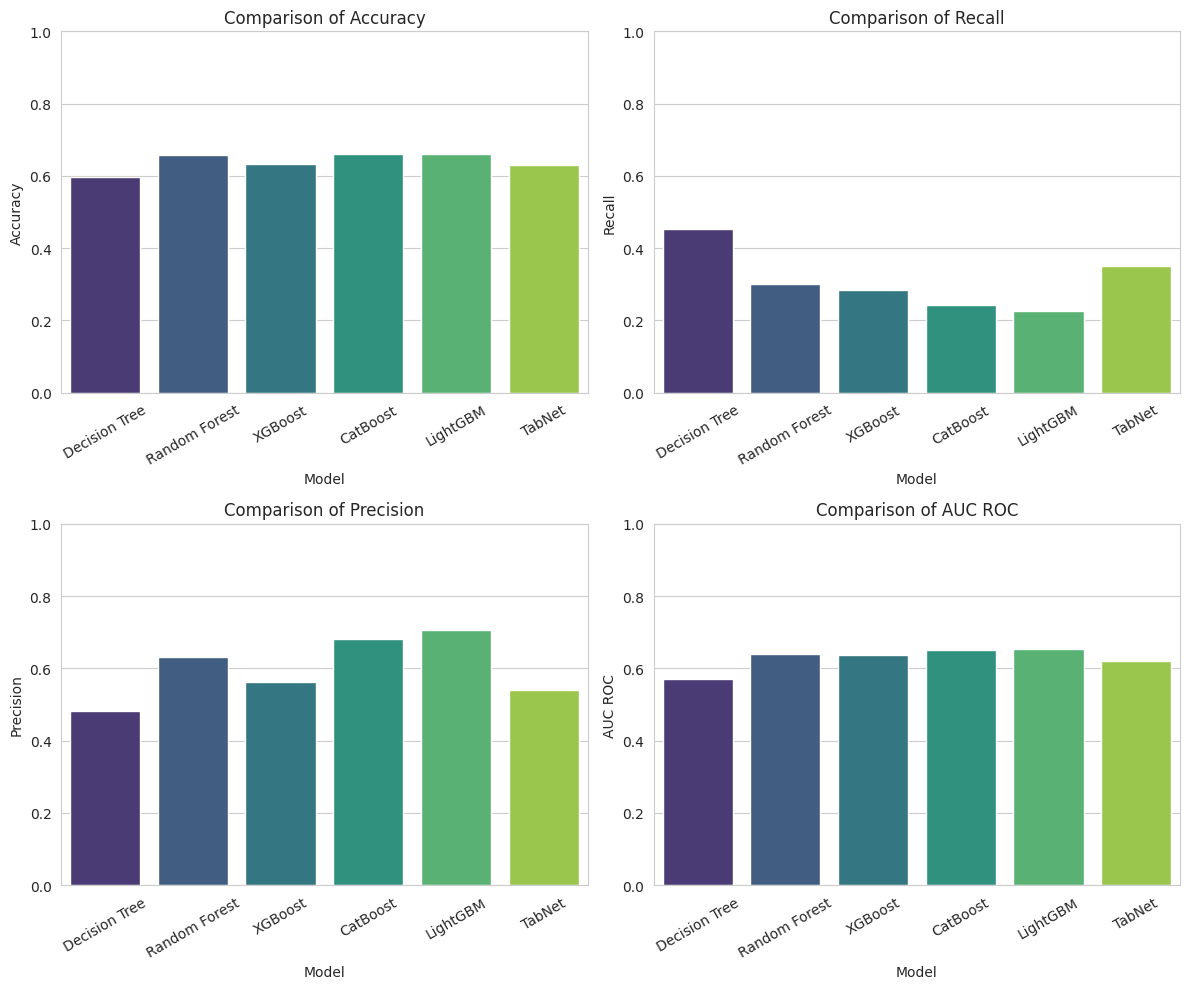

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
df = pd.read_csv("/content/water_potability.csv")  # Ensure the file is in the same directory or provide full path

# Handle missing values by imputing with median
imputer = SimpleImputer(strategy='median')
df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

# Separate features and target
X = df.drop(columns=['Potability'])
y = df['Potability']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=50, max_depth=3, eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(iterations=50, depth=3, verbose=0, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=50, max_depth=3, random_state=42),
    'TabNet': TabNetClassifier(verbose=0, seed=42)
}

# Train and evaluate models
results = []
for name, model in models.items():
    if name == 'TabNet':
        model.fit(X_train, y_train.values.ravel())  # Convert y_train to 1D
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_prob)

    results.append([name, accuracy, recall, precision, f1, auc_roc])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Recall', 'Precision', 'FMeasure', 'AUC ROC'])
print(results_df)

# Plot comparisons
sns.set_style('whitegrid')
metrics = ['Accuracy', 'Recall', 'Precision', 'AUC ROC']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Comparison of {metric}')
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(results_df['Model'], rotation=30)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
<ipython-input-5-b9440d604a52>:51: UserWarning: No early stopping will be performed, last training weights will be used.
  model.fit(X_train, y_train.values.ravel())  # Convert y_train to 1D


[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000425 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3473: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  if (await self.run_code(code, result,  async_=asy)):
/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3473: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  if (await self.run_code(code, result,  async_=asy)):
/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3473: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  if (await self.run_code(code, result,  async_=asy)):
/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3473: UserWarning: set_ticklabe

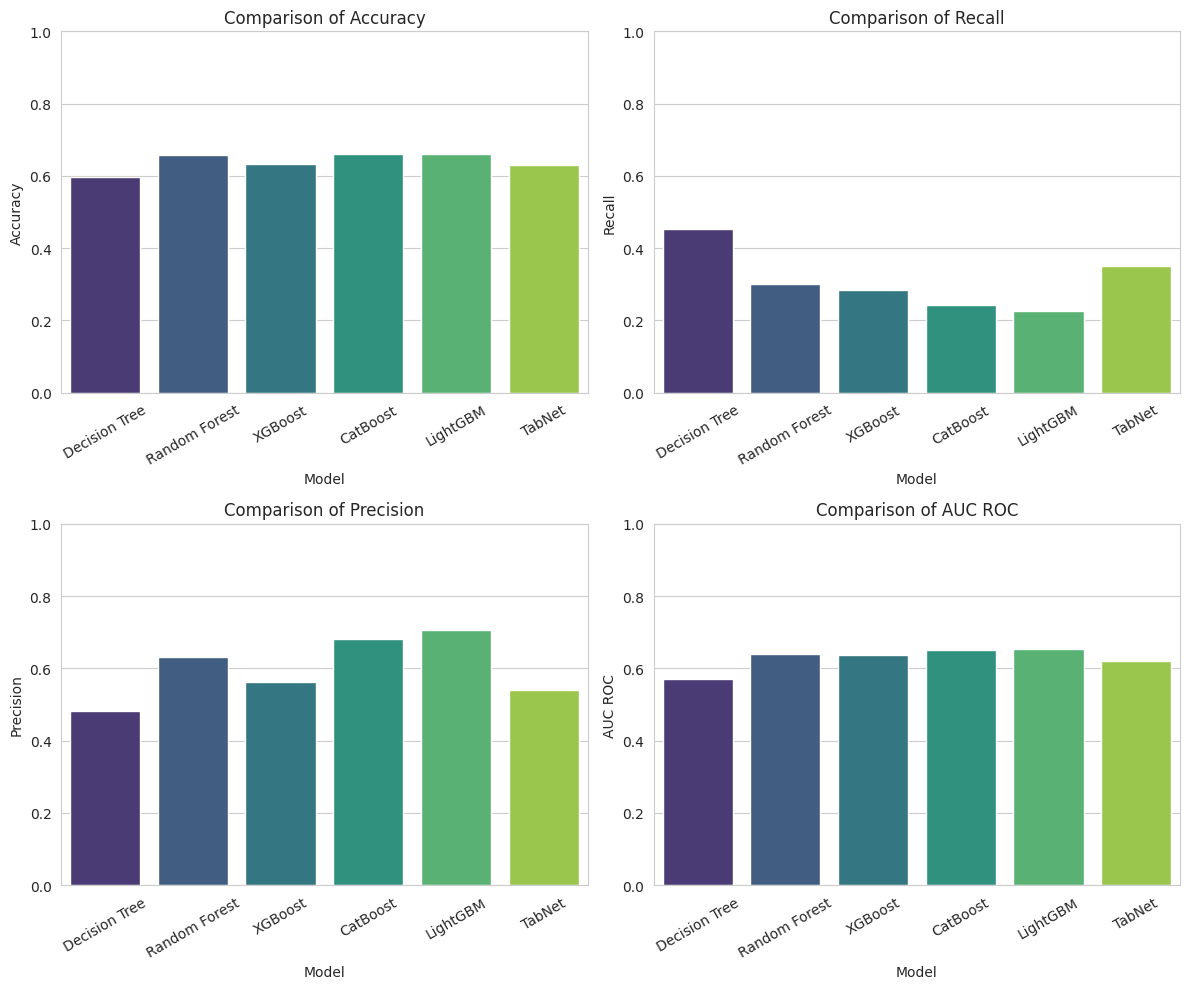

No	Model	Accuracy	Recall	Precision	F-Measure	AUC ROC
1	Decision Tree	0.596037	0.453125	0.481328	0.466801	0.570312
2	Random Forest	0.658537	0.300781	0.631148	0.407407	0.640669
3	XGBoost	0.634146	0.285156	0.561538	0.378238	0.637822
4	CatBoost	0.660061	0.242188	0.681319	0.357349	0.651680
5	LightGBM	0.661585	0.226562	0.707317	0.343195	0.652891
6	TabNet	0.629573	0.351562	0.538922	0.425532	0.619238


In [9]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
!pip install pytorch_tabnet
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# Load the dataset
df = pd.read_csv('/content/water_potability.csv')

# Separate features and target
X = df.drop('Potability', axis=1)
y = df['Potability']

# Handle missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define individual models with optimized hyperparameters

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# XGBoost
xgb = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# CatBoost
cat = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

# LightGBM
lgb = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

# TabNet
tabnet = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    optimizer_params=dict(lr=2e-2),
    verbose=0
)

# Train TabNet separately (requires numpy arrays)
X_train_np = X_train.astype(np.float32)
X_test_np = X_test.astype(np.float32)
y_train_np = y_train.values.astype(np.int64)
tabnet.fit(
    X_train=X_train_np,
    y_train=y_train_np,
    max_epochs=100,
    patience=20,
    batch_size=256,
    virtual_batch_size=128
)

# Define the ensemble
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('cat', cat),
        ('lgb', lgb)
    ],
    voting='soft',  # Soft voting for probability averaging
    weights=[1, 1, 1, 1]  # Equal weights, can be tuned
)

# Train the ensemble
ensemble.fit(X_train, y_train)

# Get TabNet predictions
tabnet_preds = tabnet.predict(X_test_np)

# Get ensemble predictions
ensemble_preds = ensemble.predict(X_test)

# Combine predictions (simple majority voting with TabNet)
final_preds = []
for e_pred, t_pred in zip(ensemble_preds, tabnet_preds):
    combined = np.bincount([e_pred, t_pred]).argmax()
    final_preds.append(combined)

# Evaluate the model
accuracy = accuracy_score(y_test, final_preds)
print(f"Final Ensemble Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, final_preds))

# If accuracy < 80%, perform hyperparameter tuning
if accuracy < 0.80:
    print("Performing hyperparameter tuning...")

    # Define parameter grid for Random Forest (example)
    rf_param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5, 10]
    }

    # Grid Search for Random Forest
    rf_grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        rf_param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    rf_grid.fit(X_train, y_train)

    # Update the ensemble with best RF
    ensemble.estimators_[0] = ('rf', rf_grid.best_estimator_)
    ensemble.fit(X_train, y_train)
    ensemble_preds = ensemble.predict(X_test)

    # Combine again
    final_preds = []
    for e_pred, t_pred in zip(ensemble_preds, tabnet_preds):
        combined = np.bincount([e_pred, t_pred]).argmax()
        final_preds.append(combined)

    # Final evaluation
    final_accuracy = accuracy_score(y_test, final_preds)
    print(f"Improved Ensemble Accuracy: {final_accuracy:.4f}")
    print("\nFinal Classification Report:")
    print(classification_report(y_test, final_preds))

# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.fit(X_train, y_train).feature_importances_
})
print("\nFeature Importance:")
print(feature_importance.sort_values('importance', ascending=False))

<ipython-input-9-85bd45556fe2>:91: UserWarning: No early stopping will be performed, last training weights will be used.
  tabnet.fit(
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:181: UserWarning: [15:42:55] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:181: UserWarning: [15:45:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)


Improved Ensemble Accuracy: 0.6738

Final Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.94      0.78       400
           1       0.73      0.26      0.39       256

    accuracy                           0.67       656
   macro avg       0.70      0.60      0.58       656
weighted avg       0.69      0.67      0.62       656


Feature Importance:
           feature  importance
4          Sulfate    0.147043
0               ph    0.141140
1         Hardness    0.124133
3      Chloramines    0.115427
2           Solids    0.112955
5     Conductivity    0.094745
8        Turbidity    0.089810
6   Organic_carbon    0.088892
7  Trihalomethanes    0.085855


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000362 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
<ipython-input-1-2300e970cf5a>:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
<ipython-input-1-2300e970cf5a>:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=30)
<ipython-input-1-2300e970cf5a>:80: FutureWarning: 


           Model  Accuracy    Recall  Precision  FMeasure   AUC ROC
0  Decision Tree  0.596037  0.453125   0.481328  0.466801  0.570312
1  Random Forest  0.658537  0.300781   0.631148  0.407407  0.640669
2        XGBoost  0.634146  0.285156   0.561538  0.378238  0.637822
3       CatBoost  0.660061  0.242188   0.681319  0.357349  0.651680
4       LightGBM  0.661585  0.226562   0.707317  0.343195  0.652891
5         TabNet  0.629573  0.351562   0.538922  0.425532  0.619238
6    Extra Trees  0.660061  0.300781   0.636364  0.408488  0.646011
7            DNN  0.597561  0.414062   0.481818  0.445378  0.610957


<ipython-input-1-2300e970cf5a>:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=30)
<ipython-input-1-2300e970cf5a>:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
<ipython-input-1-2300e970cf5a>:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=30)
<ipython-input-1-2300e970cf5a>:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['

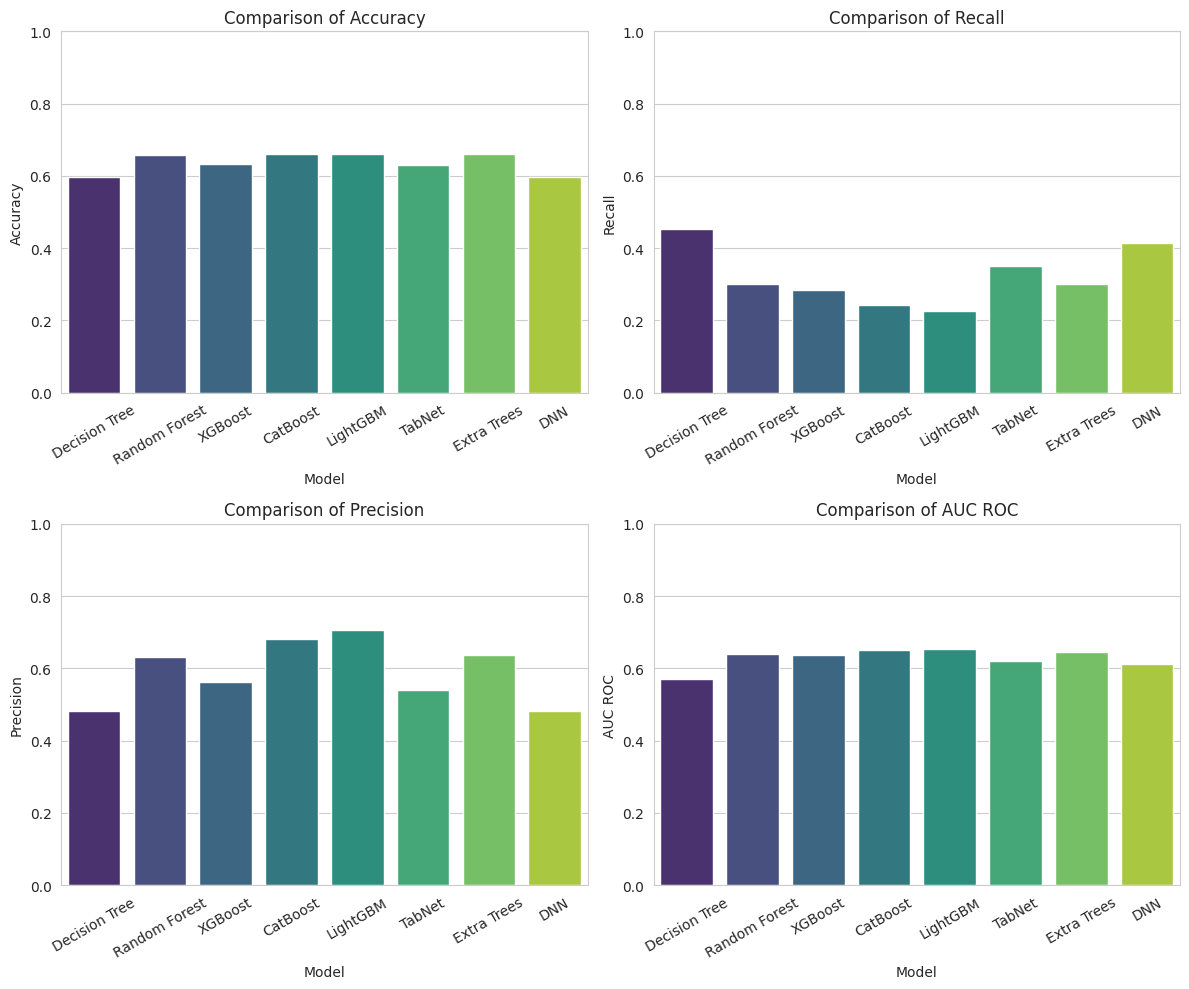

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
df = pd.read_csv("/content/water_potability.csv")  # Ensure the file is in the same directory or provide full path

# Handle missing values by imputing with median
imputer = SimpleImputer(strategy='median')
df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

# Separate features and target
X = df.drop(columns=['Potability'])
y = df['Potability']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=50, max_depth=3, eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(iterations=50, depth=3, verbose=0, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=50, max_depth=3, random_state=42),
    'TabNet': TabNetClassifier(verbose=0, seed=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=50, random_state=42),
    'DNN': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)
}

# Train and evaluate models
results = []
for name, model in models.items():
    if name == 'TabNet':
        model.fit(X_train, y_train.values.ravel())  # Convert y_train to 1D
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_prob)

    results.append([name, accuracy, recall, precision, f1, auc_roc])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Recall', 'Precision', 'FMeasure', 'AUC ROC'])
print(results_df)

# Plot comparisons
sns.set_style('whitegrid')
metrics = ['Accuracy', 'Recall', 'Precision', 'AUC ROC']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Comparison of {metric}')
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(results_df['Model'], rotation=30)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000386 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


[iter 0] loss=0.6688 val_loss=0.0000 scale=2.0000 norm=4.0000
[iter 100] loss=0.6179 val_loss=0.0000 scale=2.0000 norm=3.8363
[iter 200] loss=0.6011 val_loss=0.0000 scale=2.0000 norm=3.7875
[iter 300] loss=0.5925 val_loss=0.0000 scale=2.0000 norm=3.7636
[iter 400] loss=0.5863 val_loss=0.0000 scale=1.0000 norm=1.8734
                  Model  Accuracy    Recall  Precision  FMeasure   AUC ROC
0         Decision Tree  0.596037  0.453125   0.481328  0.466801  0.570312
1         Random Forest  0.658537  0.300781   0.631148  0.407407  0.640669
2               XGBoost  0.634146  0.285156   0.561538  0.378238  0.637822
3              CatBoost  0.660061  0.242188   0.681319  0.357349  0.651680
4              LightGBM  0.661585  0.226562   0.707317  0.343195  0.652891
5                TabNet  0.629573  0.351562   0.538922  0.425532  0.619238
6           Extra Trees  0.660061  0.300781   0.636364  0.408488  0.646011
7                   DNN  0.597561  0.414062   0.481818  0.445378  0.610957
8  Hist

<ipython-input-4-8d43d3e65015>:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
<ipython-input-4-8d43d3e65015>:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)  # Adjusted rotation and alignment
<ipython-input-4-8d43d3e65015>:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
<ipython-input-4-8d43d3e65015>:88: UserWarning: set_ticklabels() should only be used with a fixed num

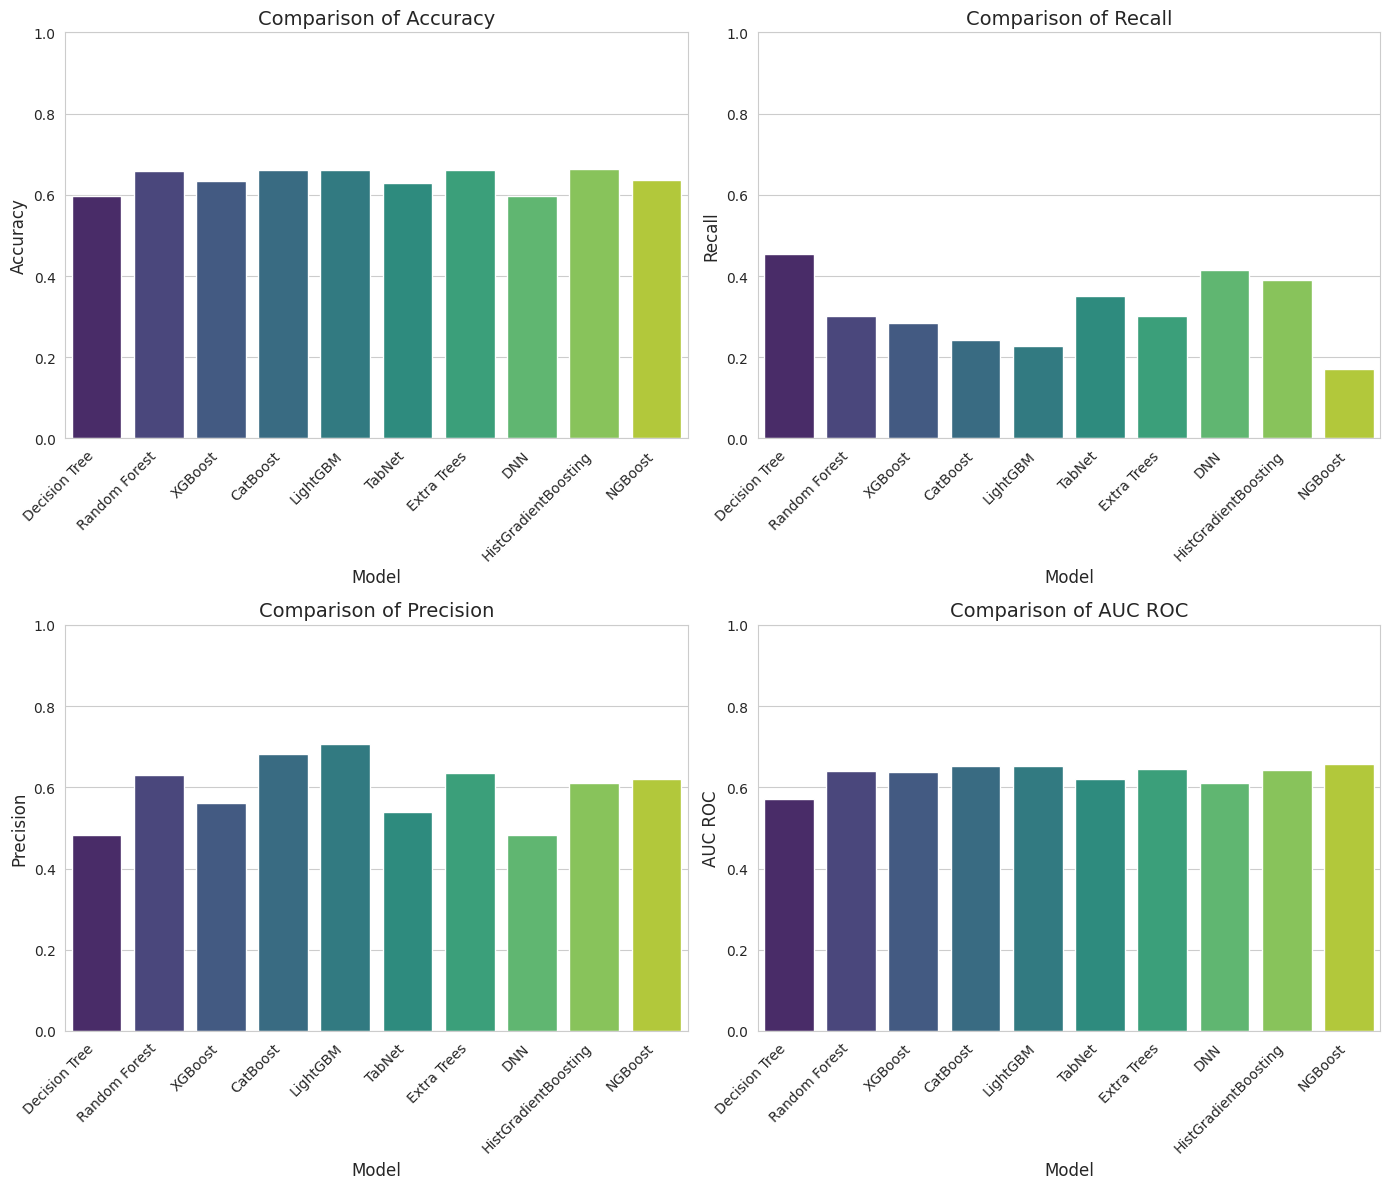

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.neural_network import MLPClassifier
from ngboost import NGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
df = pd.read_csv("/content/water_potability.csv")  # Ensure the file is in the same directory or provide full path

# Handle missing values by imputing with median
imputer = SimpleImputer(strategy='median')
df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

# Separate features and target
X = df.drop(columns=['Potability'])
y = df['Potability']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=50, max_depth=3, eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(iterations=50, depth=3, verbose=0, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=50, max_depth=3, random_state=42),
    'TabNet': TabNetClassifier(verbose=0, seed=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=50, random_state=42),
    'DNN': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'NGBoost': NGBClassifier(random_state=42)
}

# Train and evaluate models
results = []
for name, model in models.items():
    if name == 'TabNet':
        model.fit(X_train, y_train.values.ravel())  # Convert y_train to 1D
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_prob)

    results.append([name, accuracy, recall, precision, f1, auc_roc])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Recall', 'Precision', 'FMeasure', 'AUC ROC'])
print(results_df)

# Plot comparisons
sns.set_style('whitegrid')
metrics = ['Accuracy', 'Recall', 'Precision', 'AUC ROC']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))  # Increased figure size
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Comparison of {metric}', fontsize=14)
    axes[i].set_xlabel('Model', fontsize=12)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)  # Adjusted rotation and alignment

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000402 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


[iter 0] loss=0.6688 val_loss=0.0000 scale=2.0000 norm=4.0000
[iter 100] loss=0.6179 val_loss=0.0000 scale=2.0000 norm=3.8363
[iter 200] loss=0.6011 val_loss=0.0000 scale=2.0000 norm=3.7875
[iter 300] loss=0.5925 val_loss=0.0000 scale=2.0000 norm=3.7636
[iter 400] loss=0.5863 val_loss=0.0000 scale=1.0000 norm=1.8734
                   Model  Accuracy    Recall  Precision  FMeasure   AUC ROC
0          Decision Tree  0.596037  0.453125   0.481328  0.466801  0.570312
1          Random Forest  0.658537  0.300781   0.631148  0.407407  0.640669
2                XGBoost  0.634146  0.285156   0.561538  0.378238  0.637822
3               CatBoost  0.660061  0.242188   0.681319  0.357349  0.651680
4               LightGBM  0.661585  0.226562   0.707317  0.343195  0.652891
5                 TabNet  0.629573  0.351562   0.538922  0.425532  0.619238
6            Extra Trees  0.660061  0.300781   0.636364  0.408488  0.646011
7                    DNN  0.597561  0.414062   0.481818  0.445378  0.61095

<ipython-input-5-d7dca66995de>:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
<ipython-input-5-d7dca66995de>:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)  # Adjusted rotation and alignment
<ipython-input-5-d7dca66995de>:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
<ipython-input-5-d7dca66995de>:90: UserWarning: set_ticklabels() should only be used with a fixed num

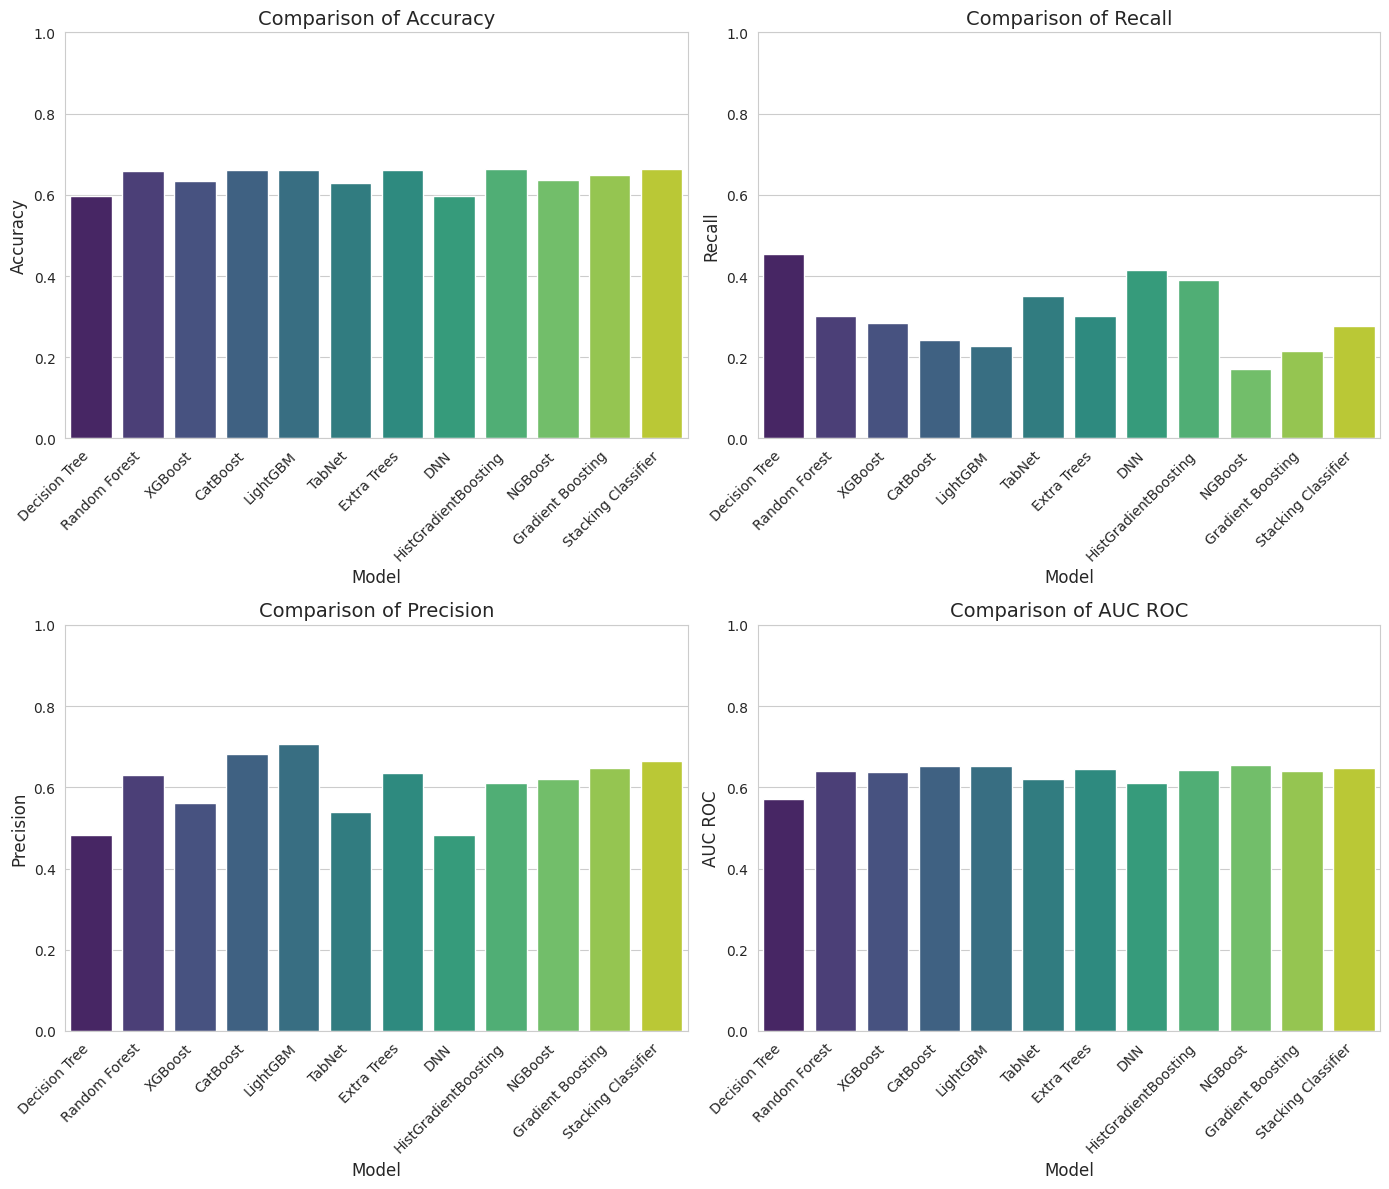

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.neural_network import MLPClassifier
from ngboost import NGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
df = pd.read_csv("/content/water_potability.csv")  # Ensure the file is in the same directory or provide full path

# Handle missing values by imputing with median
imputer = SimpleImputer(strategy='median')
df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

# Separate features and target
X = df.drop(columns=['Potability'])
y = df['Potability']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=50, max_depth=3, eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(iterations=50, depth=3, verbose=0, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=50, max_depth=3, random_state=42),
    'TabNet': TabNetClassifier(verbose=0, seed=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=50, random_state=42),
    'DNN': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'NGBoost': NGBClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    'Stacking Classifier': StackingClassifier(estimators=[('rf', RandomForestClassifier(n_estimators=10, random_state=42)), ('xgb', XGBClassifier(n_estimators=10, random_state=42))], final_estimator=MLPClassifier(max_iter=300, random_state=42))
}

# Train and evaluate models
results = []
for name, model in models.items():
    if name == 'TabNet':
        model.fit(X_train, y_train.values.ravel())  # Convert y_train to 1D
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_prob)

    results.append([name, accuracy, recall, precision, f1, auc_roc])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Recall', 'Precision', 'FMeasure', 'AUC ROC'])
print(results_df)

# Plot comparisons
sns.set_style('whitegrid')
metrics = ['Accuracy', 'Recall', 'Precision', 'AUC ROC']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))  # Increased figure size
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Comparison of {metric}', fontsize=14)
    axes[i].set_xlabel('Model', fontsize=12)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)  # Adjusted rotation and alignment

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


[iter 0] loss=0.6688 val_loss=0.0000 scale=2.0000 norm=4.0000
[iter 100] loss=0.6179 val_loss=0.0000 scale=2.0000 norm=3.8363
[iter 200] loss=0.6011 val_loss=0.0000 scale=2.0000 norm=3.7875
[iter 300] loss=0.5925 val_loss=0.0000 scale=2.0000 norm=3.7636
[iter 400] loss=0.5863 val_loss=0.0000 scale=1.0000 norm=1.8734
                   Model  Accuracy    Recall  Precision  FMeasure   AUC ROC
0          Decision Tree  0.596037  0.453125   0.481328  0.466801  0.570312
1          Random Forest  0.658537  0.300781   0.631148  0.407407  0.640669
2                XGBoost  0.634146  0.285156   0.561538  0.378238  0.637822
3               CatBoost  0.660061  0.242188   0.681319  0.357349  0.651680
4               LightGBM  0.661585  0.226562   0.707317  0.343195  0.652891
5                 TabNet  0.629573  0.351562   0.538922  0.425532  0.619238
6            Extra Trees  0.660061  0.300781   0.636364  0.408488  0.646011
7                    DNN  0.597561  0.414062   0.481818  0.445378  0.61095

<ipython-input-6-ca97bcb61d66>:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
<ipython-input-6-ca97bcb61d66>:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
<ipython-input-6-ca97bcb61d66>:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
<ipython-input-6-ca97bcb61d66>:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks(

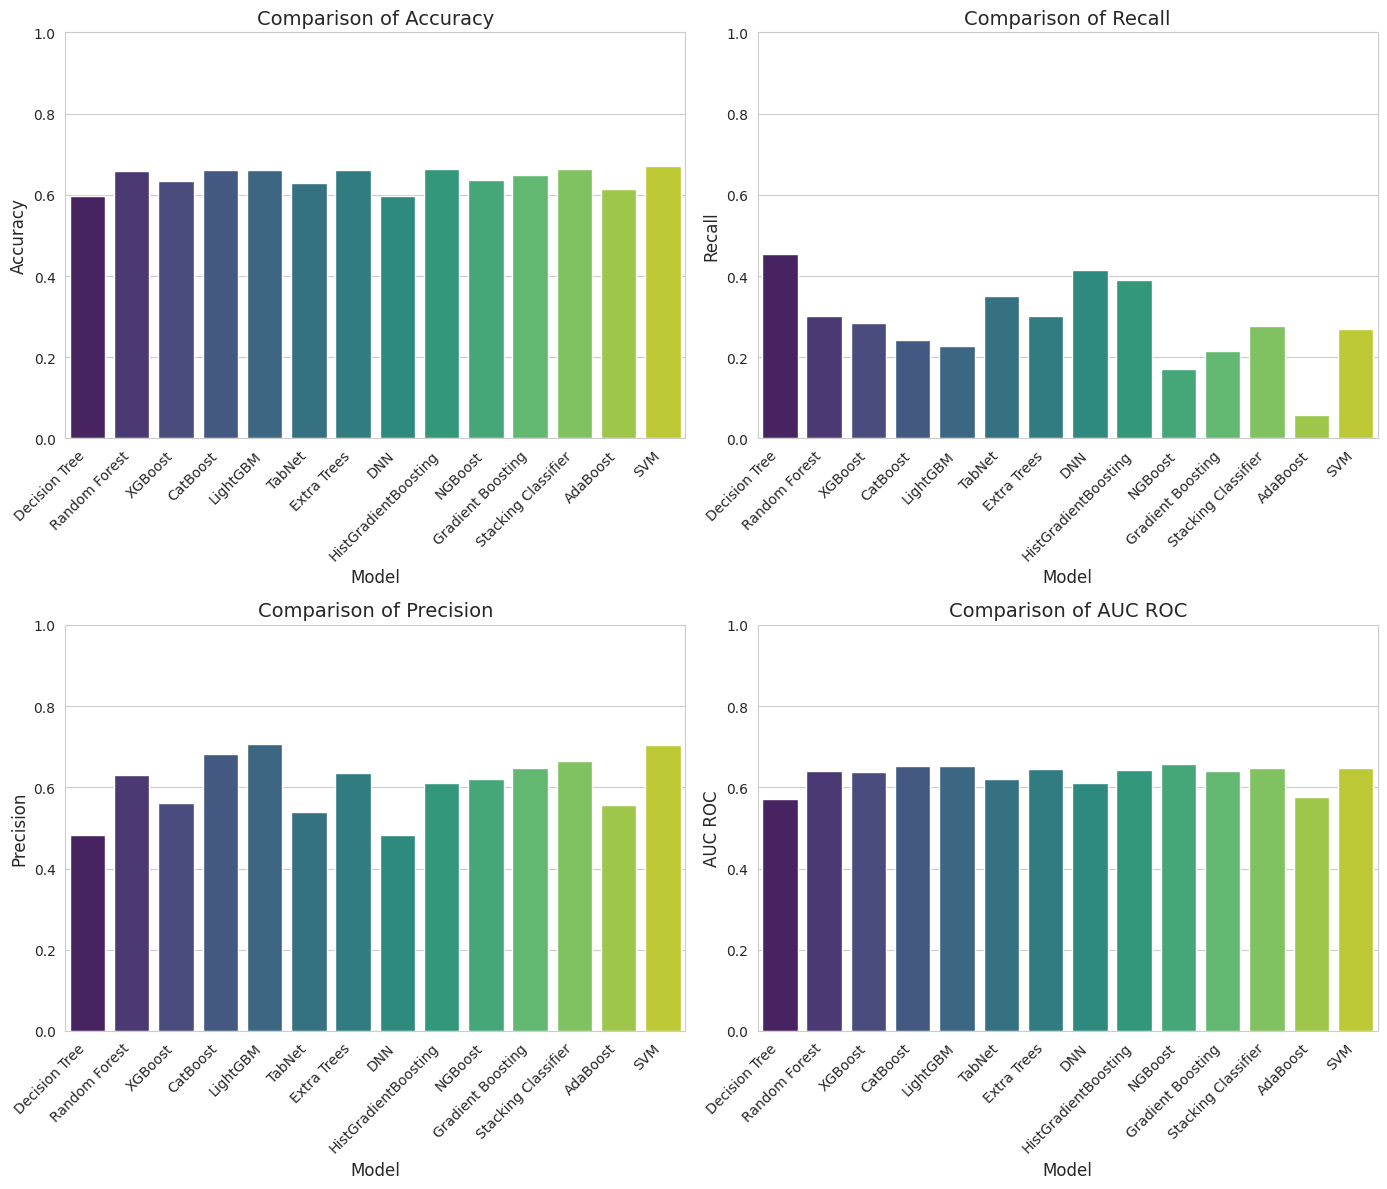

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier, StackingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.neural_network import MLPClassifier
from ngboost import NGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
df = pd.read_csv("/content/water_potability.csv")

# Handle missing values by imputing with median
imputer = SimpleImputer(strategy='median')
df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

# Separate features and target
X = df.drop(columns=['Potability'])
y = df['Potability']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=50, max_depth=3, eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(iterations=50, depth=3, verbose=0, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=50, max_depth=3, random_state=42),
    'TabNet': TabNetClassifier(verbose=0, seed=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=50, random_state=42),
    'DNN': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'NGBoost': NGBClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    'Stacking Classifier': StackingClassifier(estimators=[('rf', RandomForestClassifier(n_estimators=10, random_state=42)), ('xgb', XGBClassifier(n_estimators=10, random_state=42))], final_estimator=MLPClassifier(max_iter=300, random_state=42)),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Train and evaluate models
results = []
for name, model in models.items():
    if name == 'TabNet':
        model.fit(X_train, y_train.values.ravel())
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_prob)

    results.append([name, accuracy, recall, precision, f1, auc_roc])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Recall', 'Precision', 'FMeasure', 'AUC ROC'])
print(results_df)

# Plot comparisons
sns.set_style('whitegrid')
metrics = ['Accuracy', 'Recall', 'Precision', 'AUC ROC']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Comparison of {metric}', fontsize=14)
    axes[i].set_xlabel('Model', fontsize=12)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


[iter 0] loss=0.6688 val_loss=0.0000 scale=2.0000 norm=4.0000
[iter 100] loss=0.6179 val_loss=0.0000 scale=2.0000 norm=3.8363
[iter 200] loss=0.6011 val_loss=0.0000 scale=2.0000 norm=3.7875
[iter 300] loss=0.5925 val_loss=0.0000 scale=2.0000 norm=3.7636
[iter 400] loss=0.5863 val_loss=0.0000 scale=1.0000 norm=1.8734


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
<ipython-input-7-8ef2b445d7f4>:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')


                              Model  Accuracy    Recall  Precision  FMeasure  \
0                     Decision Tree  0.596037  0.453125   0.481328  0.466801   
1                     Random Forest  0.658537  0.300781   0.631148  0.407407   
2                           XGBoost  0.634146  0.285156   0.561538  0.378238   
3                          CatBoost  0.660061  0.242188   0.681319  0.357349   
4                          LightGBM  0.661585  0.226562   0.707317  0.343195   
5                            TabNet  0.629573  0.351562   0.538922  0.425532   
6                       Extra Trees  0.660061  0.300781   0.636364  0.408488   
7                               DNN  0.597561  0.414062   0.481818  0.445378   
8              HistGradientBoosting  0.664634  0.390625   0.609756  0.476190   
9                           NGBoost  0.635671  0.171875   0.619718  0.269113   
10                Gradient Boosting  0.647866  0.214844   0.647059  0.322581   
11              Stacking Classifier  0.6

<ipython-input-7-8ef2b445d7f4>:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
<ipython-input-7-8ef2b445d7f4>:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
<ipython-input-7-8ef2b445d7f4>:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
<ipython-input-7-8ef2b445d7f4>:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False

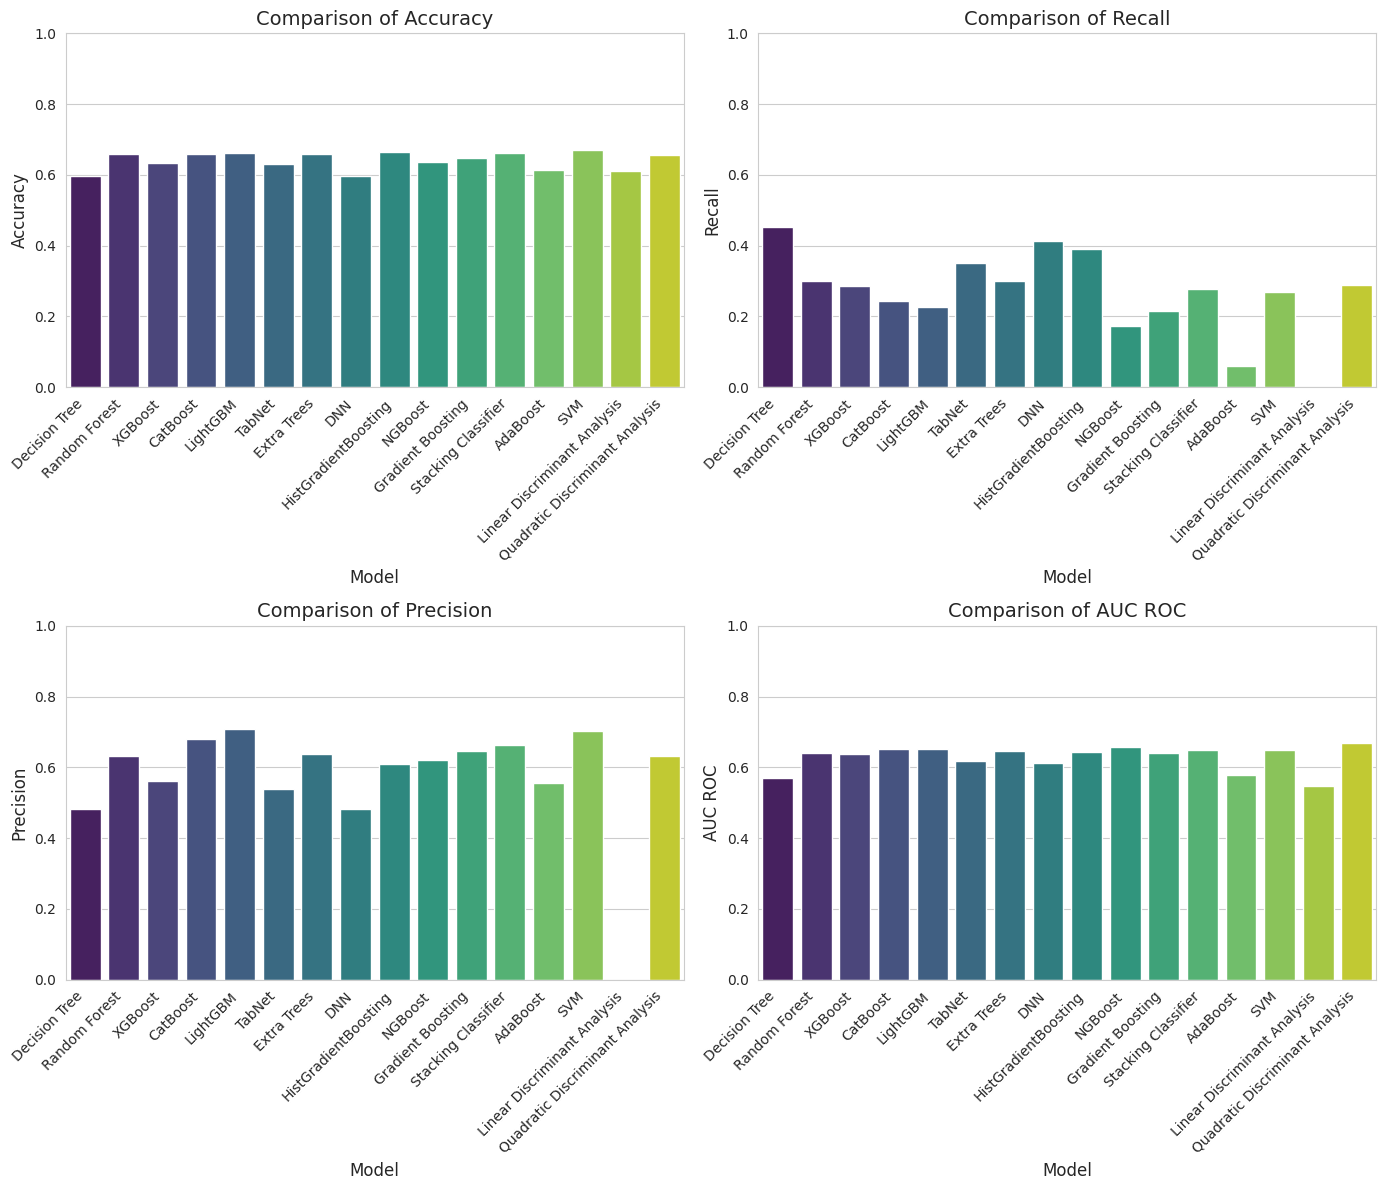

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier, StackingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.neural_network import MLPClassifier
from ngboost import NGBClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
df = pd.read_csv("/content/water_potability.csv")

# Handle missing values by imputing with median
imputer = SimpleImputer(strategy='median')
df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

# Separate features and target
X = df.drop(columns=['Potability'])
y = df['Potability']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=50, max_depth=3, eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(iterations=50, depth=3, verbose=0, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=50, max_depth=3, random_state=42),
    'TabNet': TabNetClassifier(verbose=0, seed=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=50, random_state=42),
    'DNN': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'NGBoost': NGBClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    'Stacking Classifier': StackingClassifier(estimators=[('rf', RandomForestClassifier(n_estimators=10, random_state=42)), ('xgb', XGBClassifier(n_estimators=10, random_state=42))], final_estimator=MLPClassifier(max_iter=300, random_state=42)),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Linear Discriminant Analysis': LinearDiscriminantAnalysis(),
    'Quadratic Discriminant Analysis': QuadraticDiscriminantAnalysis()
}

# Train and evaluate models
results = []
for name, model in models.items():
    if name == 'TabNet':
        model.fit(X_train, y_train.values.ravel())
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    elif name == 'Quadratic Discriminant Analysis':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else np.zeros_like(y_pred)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_prob)

    results.append([name, accuracy, recall, precision, f1, auc_roc])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Recall', 'Precision', 'FMeasure', 'AUC ROC'])
print(results_df)

# Plot comparisons
sns.set_style('whitegrid')
metrics = ['Accuracy', 'Recall', 'Precision', 'AUC ROC']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Comparison of {metric}', fontsize=14)
    axes[i].set_xlabel('Model', fontsize=12)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000392 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


[iter 0] loss=0.6688 val_loss=0.0000 scale=2.0000 norm=4.0000
[iter 100] loss=0.6179 val_loss=0.0000 scale=2.0000 norm=3.8363
[iter 200] loss=0.6011 val_loss=0.0000 scale=2.0000 norm=3.7875
[iter 300] loss=0.5925 val_loss=0.0000 scale=2.0000 norm=3.7636
[iter 400] loss=0.5863 val_loss=0.0000 scale=1.0000 norm=1.8734


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                              Model  Accuracy    Recall  Precision  FMeasure  \
0                     Decision Tree  0.596037  0.453125   0.481328  0.466801   
1                     Random Forest  0.658537  0.300781   0.631148  0.407407   
2                           XGBoost  0.634146  0.285156   0.561538  0.378238   
3                          CatBoost  0.660061  0.242188   0.681319  0.357349   
4                          LightGBM  0.661585  0.226562   0.707317  0.343195   
5                            TabNet  0.629573  0.351562   0.538922  0.425532   
6                       Extra Trees  0.660061  0.300781   0.636364  0.408488   
7                               DNN  0.597561  0.414062   0.481818  0.445378   
8              HistGradientBoosting  0.664634  0.390625   0.609756  0.476190   
9                           NGBoost  0.635671  0.171875   0.619718  0.269113   
10                Gradient Boosting  0.647866  0.214844   0.647059  0.322581   
11              Stacking Classifier  0.6

<ipython-input-8-61da4a38b3a9>:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
<ipython-input-8-61da4a38b3a9>:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
<ipython-input-8-61da4a38b3a9>:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
<ipython-input-8-61da4a38b3a9>:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tick

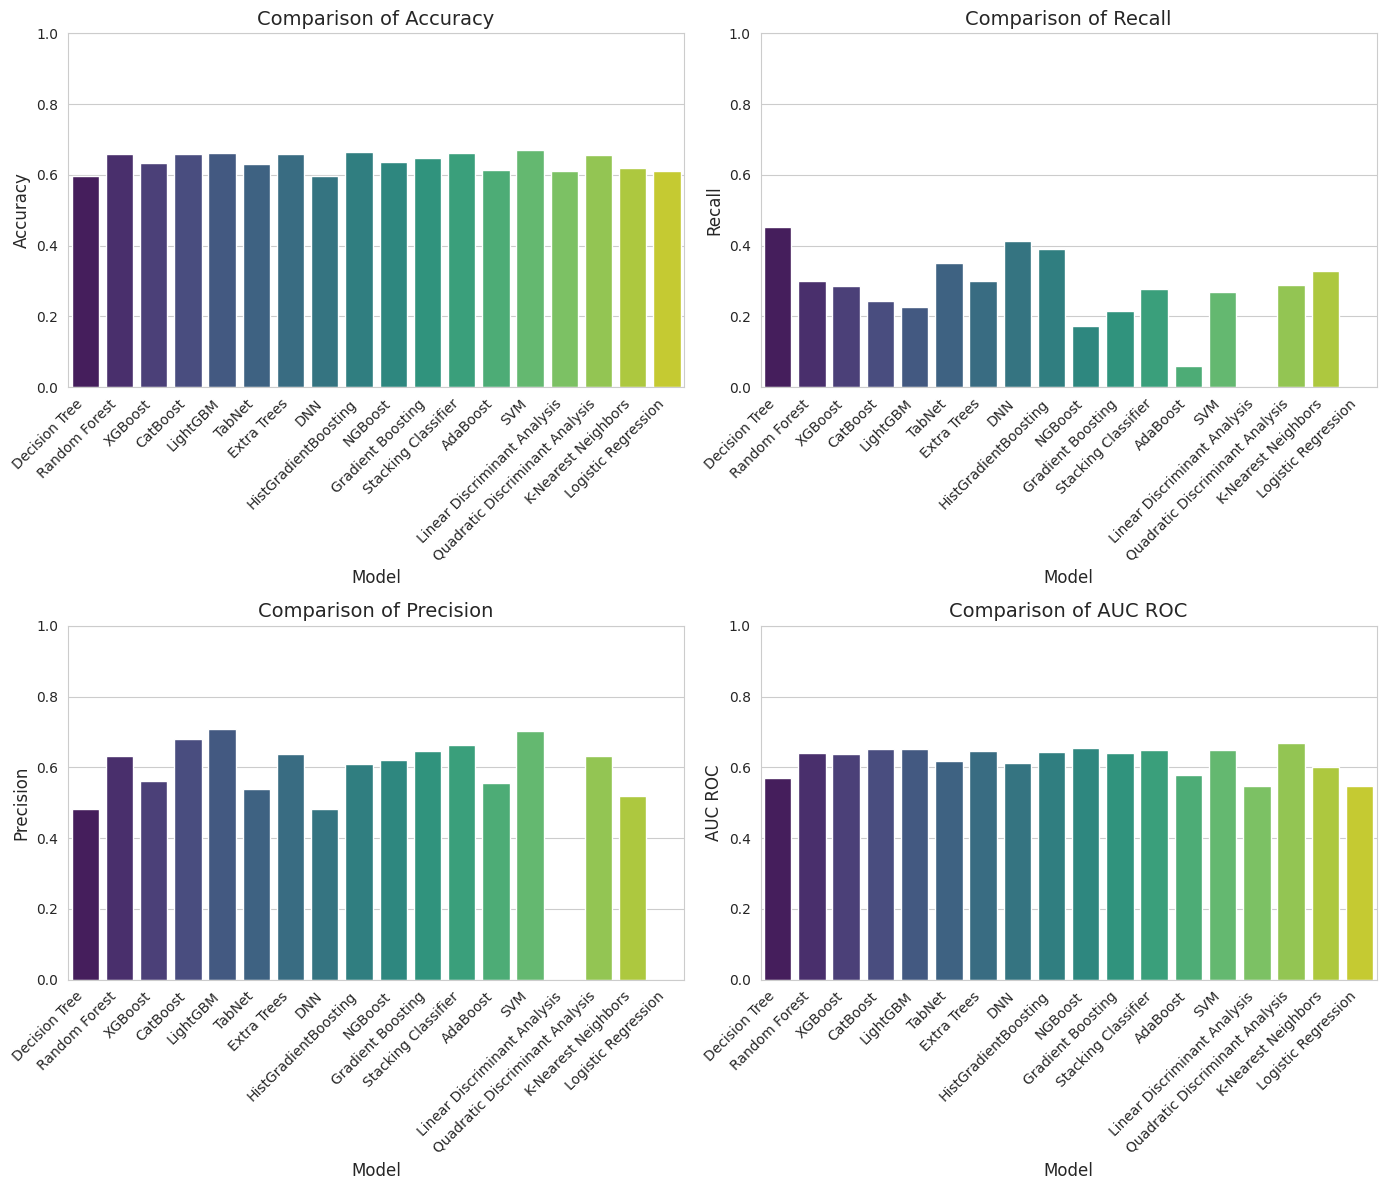

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier, StackingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.neural_network import MLPClassifier
from ngboost import NGBClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
df = pd.read_csv("/content/water_potability.csv")

# Handle missing values by imputing with median
imputer = SimpleImputer(strategy='median')
df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

# Separate features and target
X = df.drop(columns=['Potability'])
y = df['Potability']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=50, max_depth=3, eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(iterations=50, depth=3, verbose=0, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=50, max_depth=3, random_state=42),
    'TabNet': TabNetClassifier(verbose=0, seed=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=50, random_state=42),
    'DNN': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'NGBoost': NGBClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    'Stacking Classifier': StackingClassifier(estimators=[('rf', RandomForestClassifier(n_estimators=10, random_state=42)), ('xgb', XGBClassifier(n_estimators=10, random_state=42))], final_estimator=MLPClassifier(max_iter=300, random_state=42)),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Linear Discriminant Analysis': LinearDiscriminantAnalysis(),
    'Quadratic Discriminant Analysis': QuadraticDiscriminantAnalysis(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=300, random_state=42)
}

# Train and evaluate models
results = []
for name, model in models.items():
    if name == 'TabNet':
        model.fit(X_train, y_train.values.ravel())
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    elif name == 'Quadratic Discriminant Analysis':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else np.zeros_like(y_pred)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else np.zeros_like(y_pred)

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_prob)

    results.append([name, accuracy, recall, precision, f1, auc_roc])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Recall', 'Precision', 'FMeasure', 'AUC ROC'])
print(results_df)

# Plot comparisons
sns.set_style('whitegrid')
metrics = ['Accuracy', 'Recall', 'Precision', 'AUC ROC']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x=results_df['Model'], y=results_df[metric], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Comparison of {metric}', fontsize=14)
    axes[i].set_xlabel('Model', fontsize=12)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()


In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

# Load Your Dataset (Replace with actual dataset)
# df = pd.read_csv("your_dataset.csv")
# X = df.drop(columns=["target"])
# y = df["target"]

# Example Synthetic Data
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=5000, n_features=20, random_state=42)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### STACKING CLASSIFIER (Hybrid Model)
base_models = [
    ('random_forest', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('lightgbm', LGBMClassifier(n_estimators=200, random_state=42)),
    ('catboost', CatBoostClassifier(iterations=200, silent=True, random_state=42)),
    ('svm', SVC(probability=True, kernel='rbf', random_state=42)),
    ('dnn', MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42))
]

# Meta Model (Final Classifier)
meta_model = XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42)

# Stacking Model
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)
stacking_clf.fit(X_train, y_train)
stacking_pred = stacking_clf.predict(X_test)

# Accuracy
stacking_acc = accuracy_score(y_test, stacking_pred)
print(f"Stacking Classifier Accuracy: {stacking_acc:.4f}")

### VOTING CLASSIFIER (Soft Voting)
voting_clf = VotingClassifier(
    estimators=[
        ('xgboost', XGBClassifier(n_estimators=200, random_state=42)),
        ('catboost', CatBoostClassifier(iterations=200, silent=True, random_state=42)),
        ('random_forest', RandomForestClassifier(n_estimators=200, random_state=42)),
        ('lightgbm', LGBMClassifier(n_estimators=200, random_state=42)),
        ('dnn', MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42))
    ],
    voting='soft'
)
voting_clf.fit(X_train, y_train)
voting_pred = voting_clf.predict(X_test)

# Accuracy
voting_acc = accuracy_score(y_test, voting_pred)
print(f" Voting Classifier Accuracy: {voting_acc:.4f}")

### BAGGING & BOOSTING (Random Forest + XGBoost + Gradient Boosting)
bagging_boosting_clf = VotingClassifier(
    estimators=[
        ('random_forest', RandomForestClassifier(n_estimators=200, random_state=42)),
        ('xgboost', XGBClassifier(n_estimators=200, random_state=42)),
        ('gradient_boosting', GradientBoostingClassifier(n_estimators=200, random_state=42))
    ],
    voting='soft'
)
bagging_boosting_clf.fit(X_train, y_train)
bagging_boosting_pred = bagging_boosting_clf.predict(X_test)

# Accuracy
bagging_boosting_acc = accuracy_score(y_test, bagging_boosting_pred)
print(f" Bagging & Boosting Accuracy: {bagging_boosting_acc:.4f}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 2008, number of negative: 1992
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001371 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502000 -> initscore=0.008000
[LightGBM] [Info] Start training from score 0.008000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1607, number of negative: 1593
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000699 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 3200, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502188 -> initscore=0.008750
[LightGBM] [Info] Start training from score 0.008750


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

Stacking Classifier Accuracy: 0.9100


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 2008, number of negative: 1992
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000881 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502000 -> initscore=0.008000
[LightGBM] [Info] Start training from score 0.008000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 Voting Classifier Accuracy: 0.9170
 Bagging & Boosting Accuracy: 0.9140
